In [1]:
import matplotlib.pyplot as plt
import torch

Available materials:
['Au', 'Ag', 'Cu', 'Al', 'SiO2', 'Si3N4', 'cSi', 'TiO2', 'aSi']


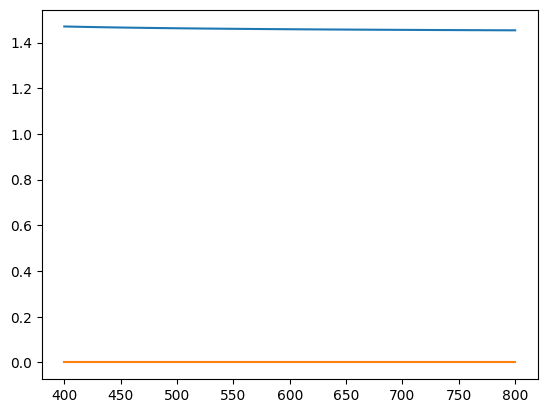

In [2]:
# Check dispersion
from dispertorch import material, list_materials
print(f"Available materials:")
print([mat for mat in list_materials().keys()])

au = material('SiO2')
wl = torch.linspace(400, 800, 41)

plt.plot(wl, au.n(wl))
plt.plot(wl, au.k(wl))


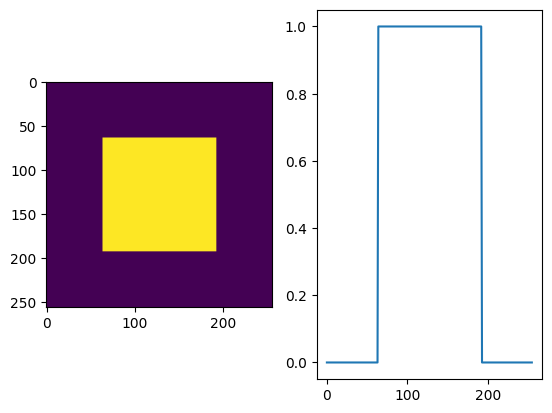

In [3]:
# chech shapes
from metashapes import Lattice, UnitCell
from metashapes.shape import Rectangle

Lx = 1.0
Ly = 1.0
lattice = Lattice.rectangular(Lx, Ly)

center = (0.5, 0.5)
size = (0.5, 0.5)
angle = 0
rect = Rectangle(center, size, angle=angle)

rect_cell = UnitCell(lattice, rect)
Nx = 256
Ny = 256

mask = rect_cell.mask(Nx, Ny, soft=False, softness=0.04)

plt.subplot(121)
plt.imshow(mask)

plt.subplot(122)
plt.plot(mask[128,:])

In [66]:
# Test for shape_fn 

## Create a MetaShapes rectangle, lattice, call `shape_fn(lattice, nx, ny)` and check
## it returns a mask.

import matplotlib.pyplot as plt
from typing import Callable

import torch

from metashapes.shape import Rectangle
from src.metarcwa.model.utils import from_metashapes
from src.metarcwa.model.lattice import Lattice

# Lattice
Lx = 400
Ly = 400
lattice = Lattice.rectangular(Lx,Ly)

centre = torch.nn.Parameter(torch.tensor([200.0, 200.0]), requires_grad=False)
size = torch.nn.Parameter(torch.tensor([200.0, 200.0]), requires_grad=False)
angle = torch.nn.Parameter(torch.tensor([10.0]), requires_grad=False)

rect = Rectangle(center=centre, size = size, angle=angle)

shape_fn_0 = from_metashapes(rect, soft = True, softness = 0.0)

mask_0 = shape_fn_0(lattice, 256, 256)
# sum = mask_0.sum()
# sum.backward()

print(centre.grad)
print(size.grad)
print(angle.grad)

#plt.imshow(mask_0)


None
None
None


{'Au': ['rakic-ld'], 'Ag': ['rakic-ld'], 'Cu': ['rakic-ld'], 'Al': ['rakic-ld'], 'SiO2': ['malitson'], 'Si3N4': ['luke'], 'cSi': ['salzberg'], 'TiO2': ['devore-o'], 'aSi': ['jellison-modine']}
None
torch.Size([50])
torch.complex64


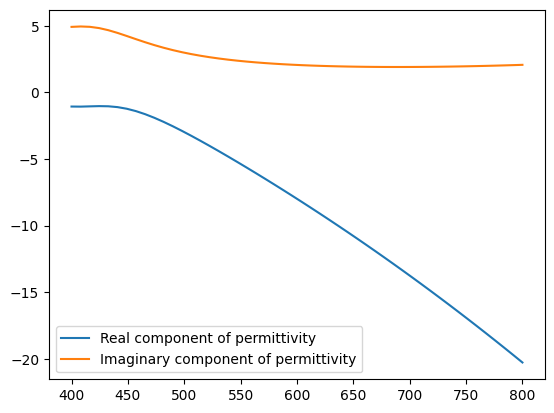

In [74]:
# Test for eps_fn

## Test epsilon with a material like gold:
## Create gold from DisperTorch, wrap it with `from_dispertorch`
## call `eps_fn(wl)` and inspect output


from dispertorch import material, list_materials
from src.metarcwa.model.utils import from_dispertorch

print(list_materials())


au = material("Au")
wl = torch.linspace(400,800,50)

au.terms[0].eps_re = torch.nn.Parameter(torch.tensor([1.0]), requires_grad=True)

eps_fn_0 = from_dispertorch(au)
eps_0 = eps_fn_0(wl)
# sum = eps_0.abs().sum()
# sum.backward()

print(au.terms[0].eps_re.grad)

print(eps_0.shape)
print(eps_0.dtype)

plt.plot(wl, eps_0.detach().real, label = "Real component of permittivity")
plt.plot(wl, eps_0.detach().imag, label = "Imaginary component of permittivity")
plt.legend()
plt.show()

In [75]:
# Test layer
# Gold rectangle in Air with a thickness of 100

from src.metarcwa.model.layer import Layer
from src.metarcwa.model.stack import Stack

def air_fn(wl):
    return torch.ones_like(wl, dtype = torch.complex64)

layer_0 = Layer(
    eps_solid_fn = eps_fn_0,
    thickness = torch.tensor(100.0),
    eps_void_fn = air_fn,
    shape_fn = shape_fn_0
)

print(layer_0)
print(layer_0.thickness)


Layer()
tensor(100.)


In [76]:
# Create Stack
# Simple stack for testing where air in the incidence and transmission medium
# with layer_0 in between

stack = Stack(
    incidence = air_fn,
    layers = [layer_0],
    transmission = air_fn,
    lattice=lattice,
    grid_shape = (256,256)
)

print(stack)
print(stack.layers)

spec = stack.spec(wl)

print(spec.layer_eps.shape)
print(spec.layer_eps.dtype)
print(spec.layer_thickness)
print(spec.eps_incidence.shape)
print(spec.eps_transmission.shape)

Stack(
  (layers): ModuleList(
    (0): Layer()
  )
  (lattice): Lattice()
)
ModuleList(
  (0): Layer()
)
torch.Size([1, 50, 256, 256])
torch.complex64
tensor([100.])
torch.Size([50])
torch.Size([50])


In [77]:
spec.layer_eps

tensor([[[[1.+0.j, 1.+0.j, 1.+0.j,  ..., 1.+0.j, 1.+0.j, 1.+0.j],
          [1.+0.j, 1.+0.j, 1.+0.j,  ..., 1.+0.j, 1.+0.j, 1.+0.j],
          [1.+0.j, 1.+0.j, 1.+0.j,  ..., 1.+0.j, 1.+0.j, 1.+0.j],
          ...,
          [1.+0.j, 1.+0.j, 1.+0.j,  ..., 1.+0.j, 1.+0.j, 1.+0.j],
          [1.+0.j, 1.+0.j, 1.+0.j,  ..., 1.+0.j, 1.+0.j, 1.+0.j],
          [1.+0.j, 1.+0.j, 1.+0.j,  ..., 1.+0.j, 1.+0.j, 1.+0.j]],

         [[1.+0.j, 1.+0.j, 1.+0.j,  ..., 1.+0.j, 1.+0.j, 1.+0.j],
          [1.+0.j, 1.+0.j, 1.+0.j,  ..., 1.+0.j, 1.+0.j, 1.+0.j],
          [1.+0.j, 1.+0.j, 1.+0.j,  ..., 1.+0.j, 1.+0.j, 1.+0.j],
          ...,
          [1.+0.j, 1.+0.j, 1.+0.j,  ..., 1.+0.j, 1.+0.j, 1.+0.j],
          [1.+0.j, 1.+0.j, 1.+0.j,  ..., 1.+0.j, 1.+0.j, 1.+0.j],
          [1.+0.j, 1.+0.j, 1.+0.j,  ..., 1.+0.j, 1.+0.j, 1.+0.j]],

         [[1.+0.j, 1.+0.j, 1.+0.j,  ..., 1.+0.j, 1.+0.j, 1.+0.j],
          [1.+0.j, 1.+0.j, 1.+0.j,  ..., 1.+0.j, 1.+0.j, 1.+0.j],
          [1.+0.j, 1.+0.j, 1.+0.j,  ..., 1